# Data visualization

Here we show how to observe the estimators produced after training a model and comparison with the desired ground truth.

In [1]:
import deepinv as dinv
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.io as sio
mpl.rcParams.update(mpl.rcParamsDefault)
from PIL import Image
from deepinv.loss.metric import PSNR
perf_psnr = PSNR()
from scipy.io import loadmat
from scipy.io import savemat
import torch.nn as nn
from torch.utils.data import DataLoader
from torchmetrics.audio import SignalNoiseRatio
snr = SignalNoiseRatio()

from utils.load_data import load_data
from utils.CP_unfolded import cp_unfolded_OpLin as cp_oplin, cp_unfolded_l as cp, cp_unfolded_Lexp as cp_l, cp_unfolded_LSTexp as cp_lst
from utils.database_gradient_descent import load_model

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = loadmat("data_exemple/data_exemple_covid_best_validation_OpLin_mat.mat", squeeze_me = True)
model = cp_oplin.CPunfolded_OpLin_mat('cpu', 490, 10, 'adam', scheduler = False, learning_rate=1e-4)
load_model(model, 'model_exemple/model_exemple_covid_best_validation_OpLin_mat.pth')

/Users/benji/Documents/Centrale_Nantes/unrolling-internship/utils/database_gradient_descent.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  param_model = torch.load(ini

### Training dataset

We visualize the estimator obtained after training $\Gamma$ (see [`train_demo`](train_demo.ipynb)) on a country from the training dataset. We can see that we are close to the ground truth.

<Figure size 1950x1000 with 0 Axes>

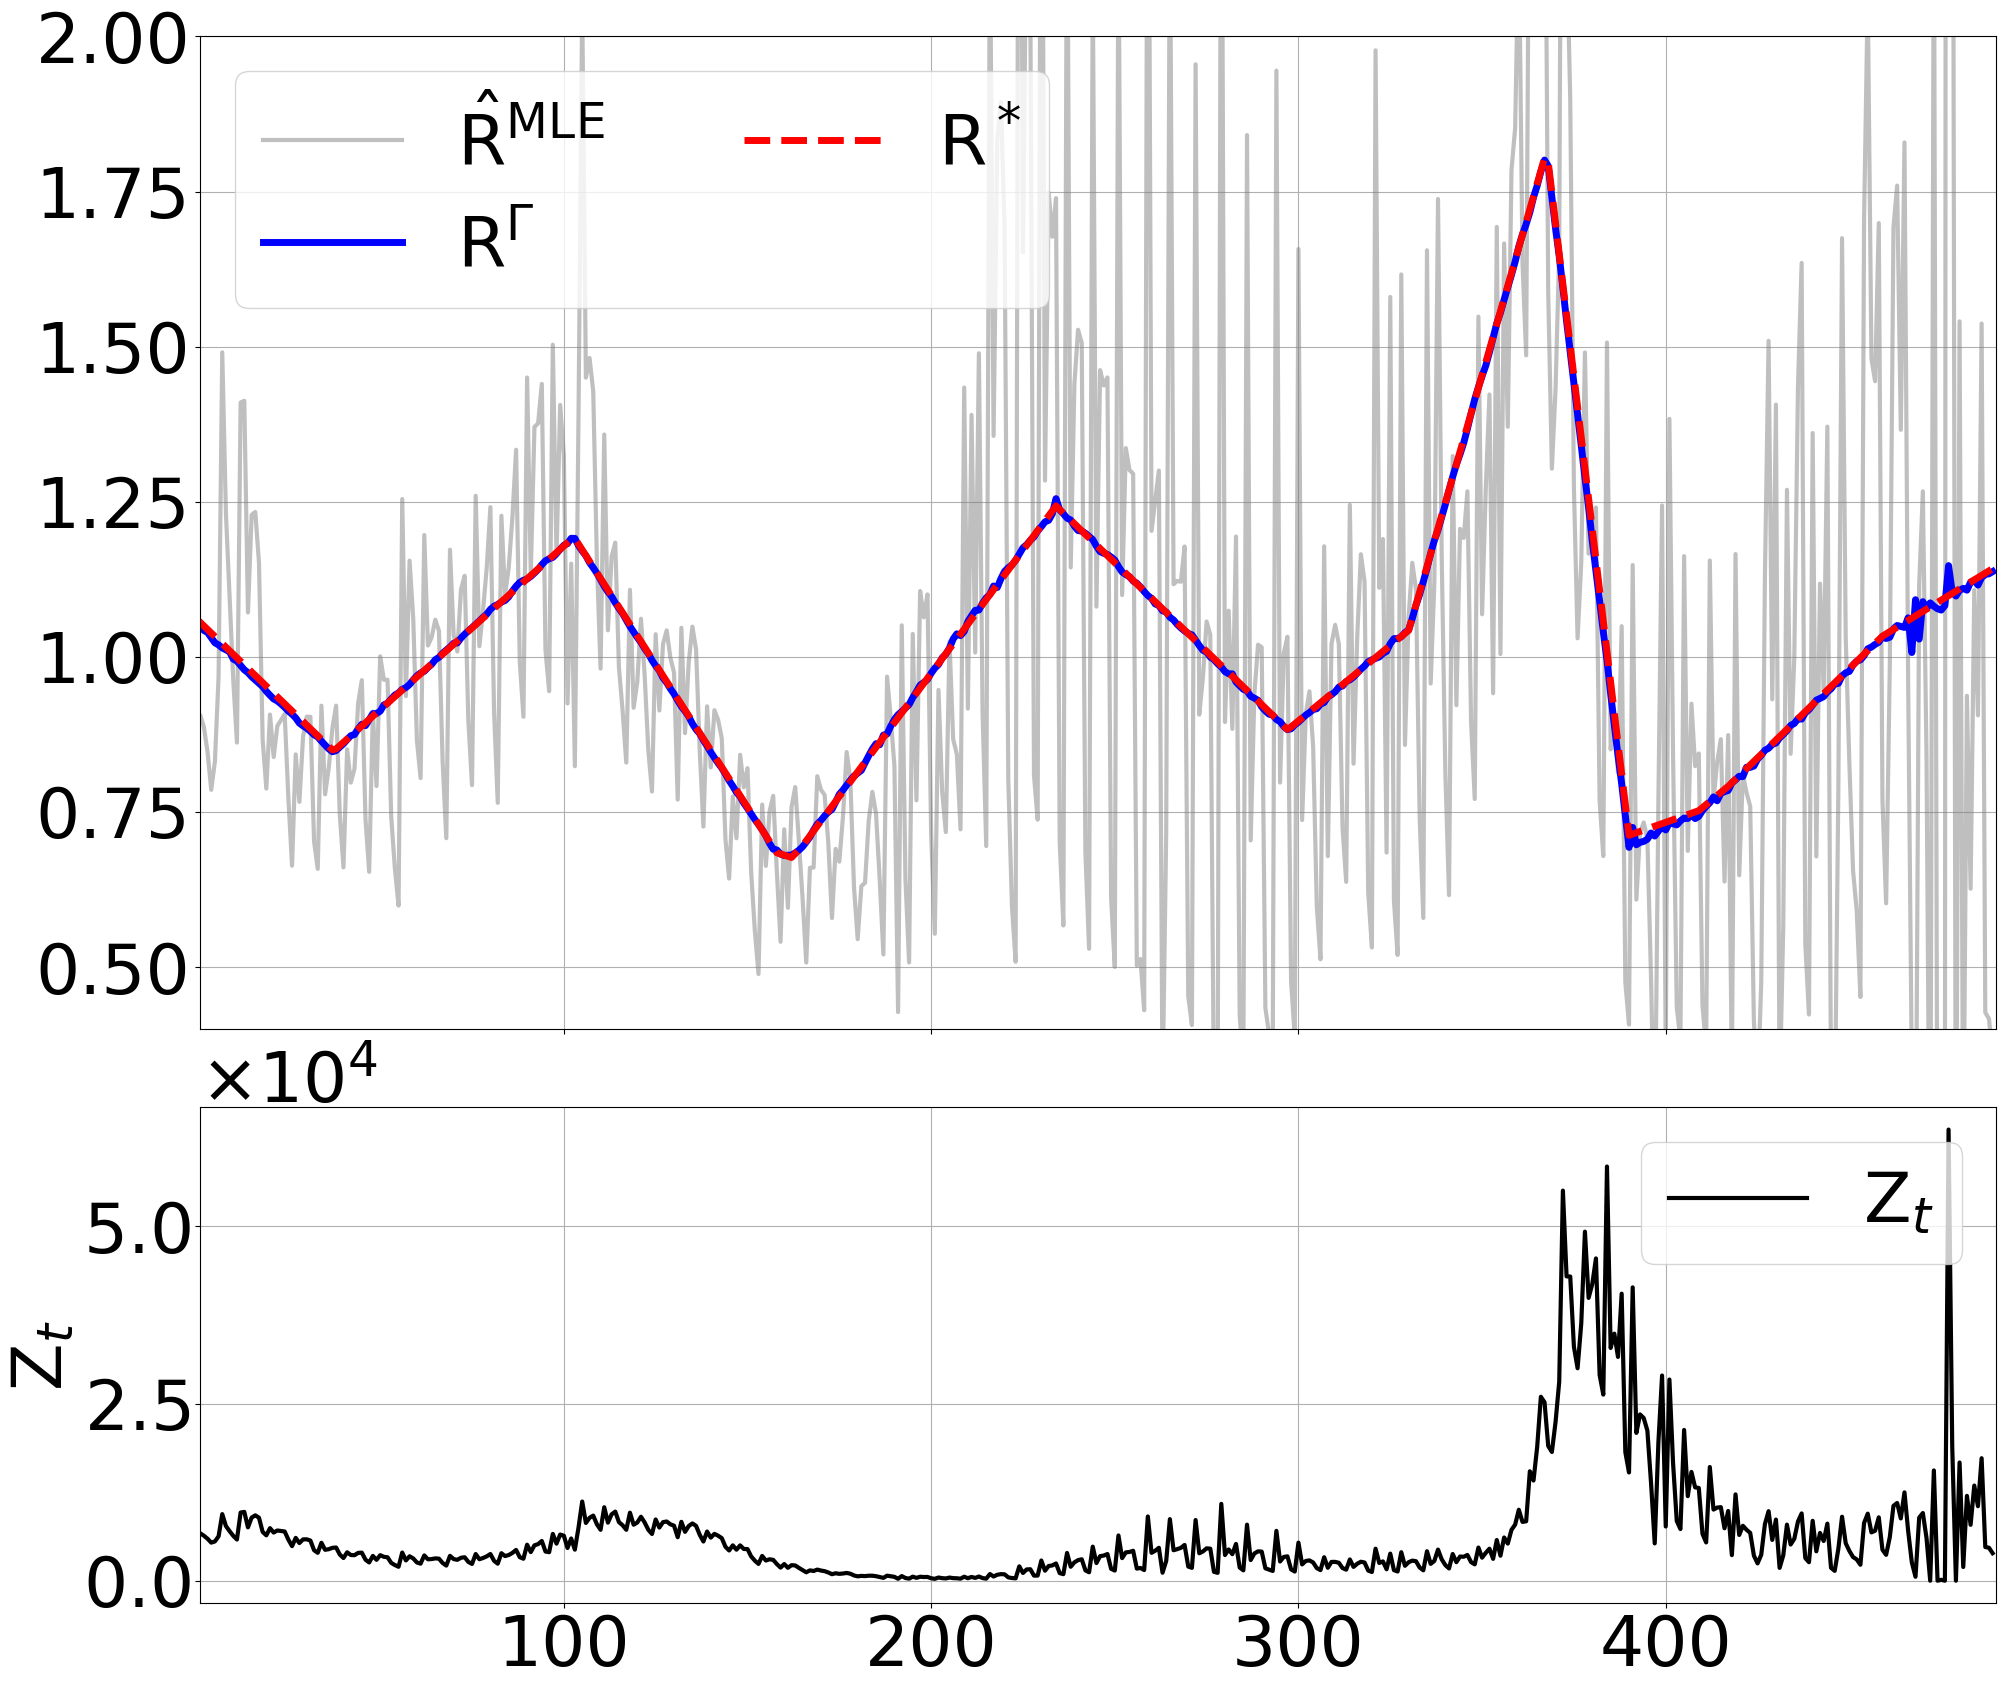

In [3]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates

mpl.rcParams["xtick.labelsize"] = 50
mpl.rcParams["ytick.labelsize"] = 50
mpl.rcParams["axes.titlesize"] = 50
plt.rc("axes", labelsize = 42.5)
plt.rc("legend", fontsize = 50)
plt.figure(figsize=(19.5, 10))

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

country = "Canada"

Z, PhiZ, R_lmb, date = load_data(country, dataset='dataset_covid/data_train')
formattedDates = [mdates.datestr2num(t) for t in date]
#Z = sliding_median(Z)
Z = torch.tensor(Z[:], dtype=torch.float).unsqueeze(0)
PhiZ = torch.tensor(PhiZ[:], dtype=torch.float).unsqueeze(0)
R_lmb_torch = torch.tensor(R_lmb, dtype=torch.float).unsqueeze(0)

std_Z = Z.std(dim = None, keepdims = True, unbiased=False)
Z_std = Z/std_Z
PhiZ_std = PhiZ/std_Z
R_std = Z_std/PhiZ_std

out = model.forward(R_std.unsqueeze(0), Z_std.unsqueeze(0), PhiZ_std.unsqueeze(0))

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

fig = plt.figure(figsize=(19.5, 17))
gs = GridSpec(2, 1, height_ratios=[4, 2])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

axes = [ax0, ax1]

axes[0].plot((Z_std/PhiZ_std)[0], alpha = 0.5, color = 'grey', label = r'$\hat{\mathsf{R}}^{\mathrm{MLE}}$', linewidth = 3)
axes[0].plot(out.detach().numpy()[0][0], label = r'$\mathsf{R}^{\Gamma}$', color = 'blue', linewidth = 5)
axes[0].plot(R_lmb_torch[0], '--', label = r'$\mathsf{R}^*$', color = 'red', linewidth = 5)

axes[0].set_ylabel("", fontsize = 50)
axes[0].set_ylim([0.4, 2])
axes[0].legend(ncol = 2, fontsize=50)
axes[0].grid()
axes[0].tick_params(labelbottom=False)

axes[1].plot(Z[0], label = r'$\mathsf{Z}_t$', color = 'black', linewidth = 3)
axes[1].legend(loc = 'upper right', fontsize=50)
axes[1].set_ylabel(r'$\mathsf{Z}_t$', fontsize = 50)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_xlim([1, 490])
axes[1].grid()

plt.tight_layout()
plt.show()

### Validation dataset

We visualize the estimator obtained after training $\Gamma$ (see [`train_demo`](train_demo.ipynb)) on a country from the validation dataset. The network's generalization power is limited.

<Figure size 1950x1000 with 0 Axes>

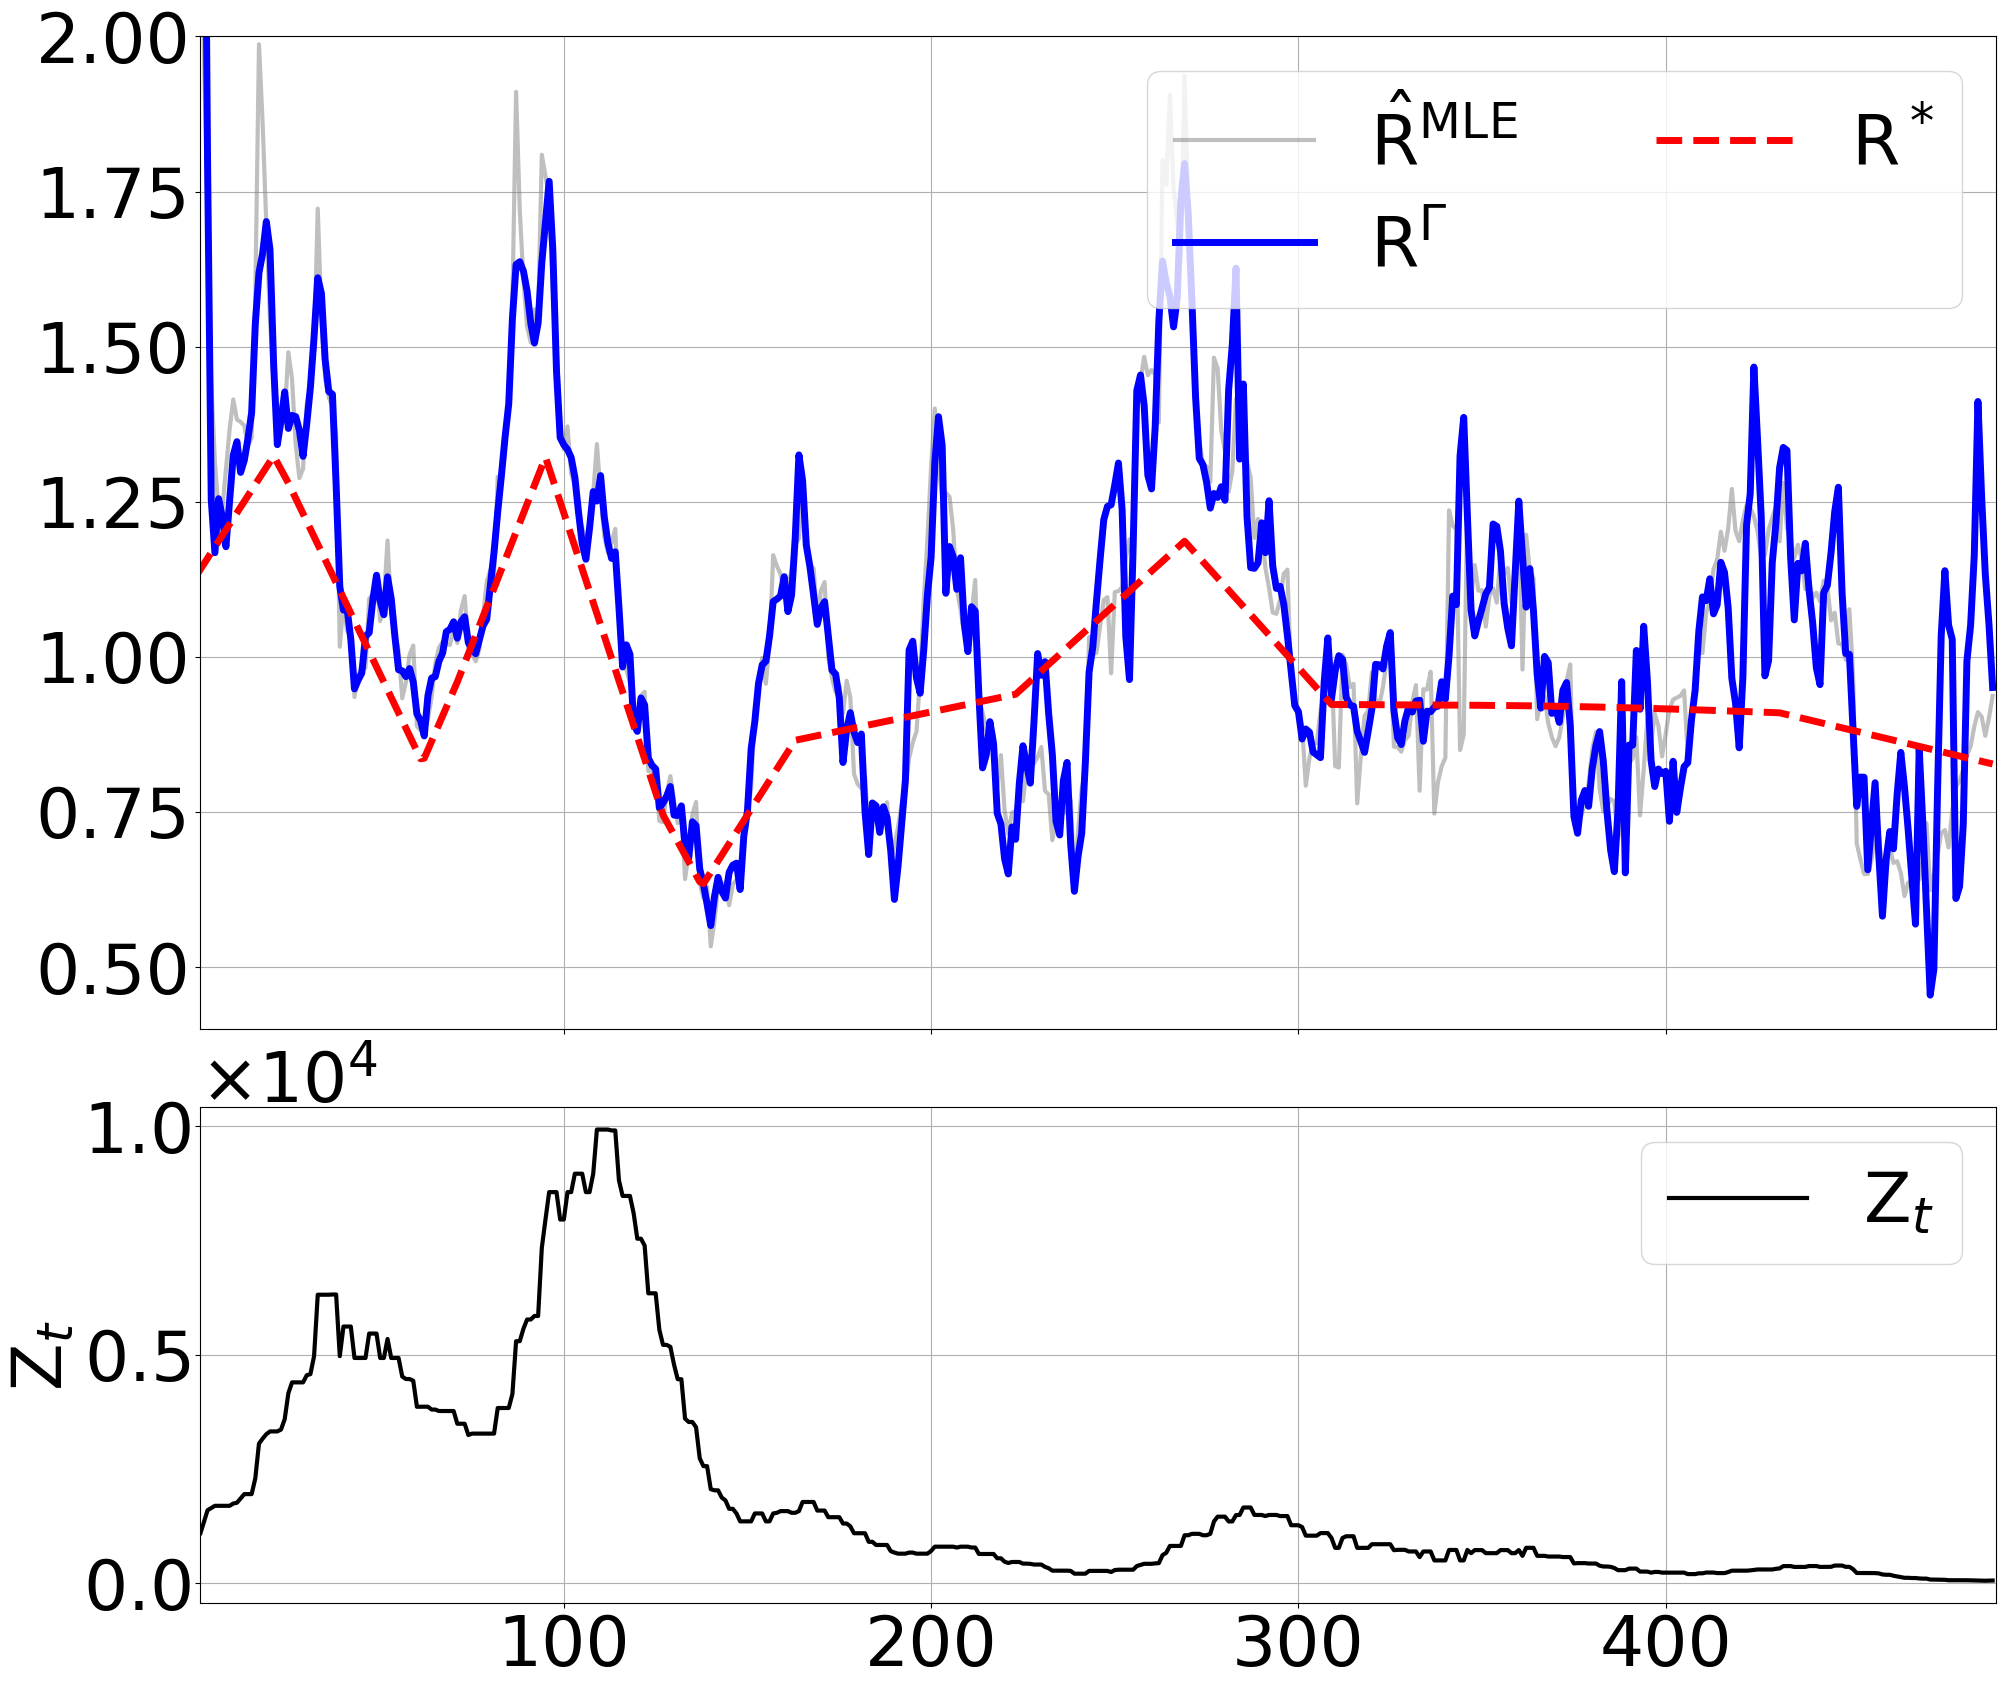

In [4]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates

mpl.rcParams["xtick.labelsize"] = 50
mpl.rcParams["ytick.labelsize"] = 50
mpl.rcParams["axes.titlesize"] = 50
plt.rc("axes", labelsize = 42.5)
plt.rc("legend", fontsize = 50)
plt.figure(figsize=(19.5, 10))

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

country = "Croatia"

Z, PhiZ, R_lmb, date = load_data(country, dataset='dataset_covid/data_validation')
formattedDates = [mdates.datestr2num(t) for t in date]
Z = torch.tensor(Z[:], dtype=torch.float).unsqueeze(0)
PhiZ = torch.tensor(PhiZ[:], dtype=torch.float).unsqueeze(0)
R_lmb_torch = torch.tensor(R_lmb, dtype=torch.float).unsqueeze(0)

std_Z = Z.std(dim = None, keepdims = True, unbiased=False)
Z_std = Z/std_Z
PhiZ_std = PhiZ/std_Z
R_std = Z_std/PhiZ_std

out = model.forward(R_std.unsqueeze(0), Z_std.unsqueeze(0), PhiZ_std.unsqueeze(0))

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

fig = plt.figure(figsize=(19.5, 17))
gs = GridSpec(2, 1, height_ratios=[4, 2])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

axes = [ax0, ax1]

axes[0].plot((Z_std/PhiZ_std)[0], alpha = 0.5, color = 'grey', label = r'$\hat{\mathsf{R}}^{\mathrm{MLE}}$', linewidth = 3)
axes[0].plot(out.detach().numpy()[0][0], label = r'$\mathsf{R}^{\Gamma}$', color = 'blue', linewidth = 5)
axes[0].plot(R_lmb_torch[0], '--', label = r'$\mathsf{R}^*$', color = 'red', linewidth = 5)

axes[0].set_ylabel("", fontsize = 50)
axes[0].set_ylim([0.4, 2])
axes[0].legend(ncol = 2, fontsize=50)
axes[0].grid()
axes[0].tick_params(labelbottom=False)

axes[1].plot(Z[0], label = r'$\mathsf{Z}_t$', color = 'black', linewidth = 3)
axes[1].legend(loc = 'upper right', fontsize=50)
axes[1].set_ylabel(r'$\mathsf{Z}_t$', fontsize = 50)
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_xlim([1, 490])
axes[1].grid()

plt.tight_layout()
plt.show()